# Retention Rates

Full comparison and analysis of the retention rates.

In this notebook we present the first full comparison and analysis across aggregation levels of some simple metrics.

## Data & Packages

In [1]:
# Main packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Clustering packages
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score,adjusted_rand_score

# Optimisation packages
from scipy.optimize import linear_sum_assignment

# Parallel processing packages
from joblib import Parallel, delayed

In [2]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [3]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

## Functions & Global info

In [4]:
# Time conversions
seconds_in_day = 60 * 60 * 24


In [5]:
# FUNCTION - build features dataframe
def build_features(df,agg_hour_level):

    agg_seconds = agg_hour_level * 60 * 60

    return (
        df.with_columns(
            bucket = pl.col('time') // agg_seconds,
            theta = ((pl.col('time') % seconds_in_day)/ seconds_in_day) * 2 * np.pi,
            is_failure = (pl.col('outcome') == 'Fail').cast(pl.Int8),
        )
        .group_by(['src_user','bucket'])
        .agg(
            n_events = pl.len(),
            failure_ratio = pl.col('is_failure').mean(),
            n_distinct_dest = pl.col('dest_comp').n_unique(),
            n_distinct_src = pl.col('src_comp').n_unique(),
            c_bar = pl.col('theta').cos().mean(),
            s_bar = pl.col('theta').sin().mean(),
        )
        .with_columns(
             log_n_events=pl.col("n_events").log1p(),
             log_n_distinct_dest=pl.col("n_distinct_dest").log1p(),
             log_n_distinct_src=pl.col("n_distinct_src").log1p(),
        )
        .collect()
    )

In [6]:
# Relevant feauture columns
feature_cols = [
    "log_n_events",
    "failure_ratio",
    "log_n_distinct_dest",
    "log_n_distinct_src",
    "c_bar",
    "s_bar",
]

In [7]:
# FUNCTION - process features for clustering 
def cluster_preprocess(features_df,feature_cols,week):

    lb = (week - 1) * buckets_per_week
    ub = lb + buckets_per_week - 1

    features_week = features_df.filter(pl.col('bucket').is_between(lb,ub))

    X = features_week.select(feature_cols).to_numpy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return features_week, X_scaled

# 1 HOUR

In [8]:
# Time aggregation
agg_hour_level = 1

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [9]:
# Create features dataframe
features_df = build_features(df,agg_hour_level)

In [10]:
# Cluster for each week
n_weeks = 8
k = 3
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled = cluster_preprocess(features_df, feature_cols, week=week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10) 
    labels = km.fit_predict(X_scaled)   

    features_week = (features_week.with_columns(pl.Series("cluster", labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

In [11]:
JACARD = np.zeros((n_weeks - 1,k,k))
aligned_labels = {}

for week in range(1,n_weeks):
    
    w_curr = weekly_results[week].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next, on=['src_user', 'relative_bucket'], how='inner', suffix='_next')

    labels_curr = overlap['cluster'].to_numpy()
    labels_next = overlap['cluster_next'].to_numpy()

    for i in range(k):
        mask_i = (labels_curr == i)
        
        for j in range(k):
            mask_j = labels_next == j
            intersection = np.sum(mask_i & mask_j)
            union = np.sum(mask_i | mask_j)
            JACARD[week - 1, i,j] = intersection/union 

    _, col_ind = linear_sum_assignment(JACARD[week - 1], maximize=True)

    mapping = {col_ind[c]: c for c in range(k)}
    labels_next = np.array([mapping[label] for label in labels_next])

    aligned_labels[week] = {
        'src_user': overlap['src_user'].to_numpy(),
        'relative_bucket': overlap['relative_bucket'].to_numpy(),
        'labels_curr': labels_curr,
        'labels_next': labels_next,
    }

In [12]:
retention_rates = []

for week in range(1,n_weeks):

    labels_curr = aligned_labels[week]['labels_curr']
    labels_next =aligned_labels[week]['labels_next']

    retention_rates.append(np.mean(labels_curr == labels_next))

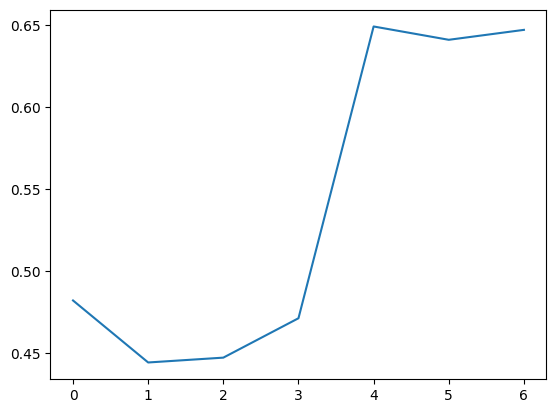

In [13]:
plt.plot(retention_rates)

## 3 Hours

In [14]:
# Time aggregation
agg_hour_level = 3

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [15]:
# Create features dataframe
features_df = build_features(df,agg_hour_level)

In [16]:
# Cluster for each week
n_weeks = 8
k = 3
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled = cluster_preprocess(features_df, feature_cols, week=week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10) 
    labels = km.fit_predict(X_scaled)   

    features_week = (features_week.with_columns(pl.Series("cluster", labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

In [17]:
JACARD = np.zeros((n_weeks - 1,k,k))
aligned_labels = {}

for week in range(1,n_weeks):
    
    w_curr = weekly_results[week].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next, on=['src_user', 'relative_bucket'], how='inner', suffix='_next')

    labels_curr = overlap['cluster'].to_numpy()
    labels_next = overlap['cluster_next'].to_numpy()

    for i in range(k):
        mask_i = (labels_curr == i)
        
        for j in range(k):
            mask_j = labels_next == j
            intersection = np.sum(mask_i & mask_j)
            union = np.sum(mask_i | mask_j)
            JACARD[week - 1, i,j] = intersection/union 

    _, col_ind = linear_sum_assignment(JACARD[week - 1], maximize=True)

    mapping = {col_ind[c]: c for c in range(k)}
    labels_next = np.array([mapping[label] for label in labels_next])

    aligned_labels[week] = {
        'src_user': overlap['src_user'].to_numpy(),
        'relative_bucket': overlap['relative_bucket'].to_numpy(),
        'labels_curr': labels_curr,
        'labels_next': labels_next,
    }

In [18]:
retention_rates = []

for week in range(1,n_weeks):

    labels_curr = aligned_labels[week]['labels_curr']
    labels_next =aligned_labels[week]['labels_next']

    retention_rates.append(np.mean(labels_curr == labels_next))

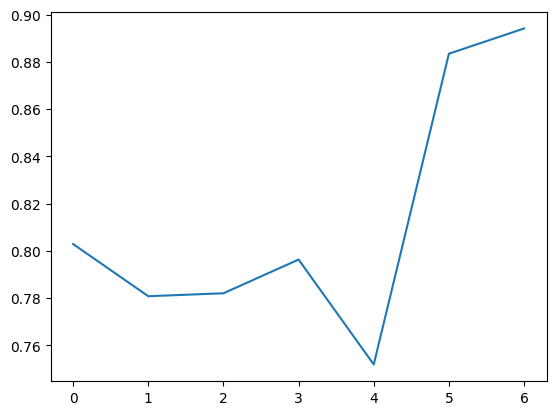

In [19]:
plt.plot(retention_rates)

## 6 Hours

In [20]:
# Time aggregation
agg_hour_level = 6

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [21]:
# Create features dataframe
features_df = build_features(df,agg_hour_level)

In [22]:
# Cluster for each week
n_weeks = 8
k = 3
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled = cluster_preprocess(features_df, feature_cols, week=week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10) 
    labels = km.fit_predict(X_scaled)   

    features_week = (features_week.with_columns(pl.Series("cluster", labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

In [23]:
JACARD = np.zeros((n_weeks - 1,k,k))
aligned_labels = {}

for week in range(1,n_weeks):
    
    w_curr = weekly_results[week].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next, on=['src_user', 'relative_bucket'], how='inner', suffix='_next')

    labels_curr = overlap['cluster'].to_numpy()
    labels_next = overlap['cluster_next'].to_numpy()

    for i in range(k):
        mask_i = (labels_curr == i)
        
        for j in range(k):
            mask_j = labels_next == j
            intersection = np.sum(mask_i & mask_j)
            union = np.sum(mask_i | mask_j)
            JACARD[week - 1, i,j] = intersection/union 

    _, col_ind = linear_sum_assignment(JACARD[week - 1], maximize=True)

    mapping = {col_ind[c]: c for c in range(k)}
    labels_next = np.array([mapping[label] for label in labels_next])

    aligned_labels[week] = {
        'src_user': overlap['src_user'].to_numpy(),
        'relative_bucket': overlap['relative_bucket'].to_numpy(),
        'labels_curr': labels_curr,
        'labels_next': labels_next,
    }

In [24]:
retention_rates = []

for week in range(1,n_weeks):

    labels_curr = aligned_labels[week]['labels_curr']
    labels_next =aligned_labels[week]['labels_next']

    retention_rates.append(np.mean(labels_curr == labels_next))

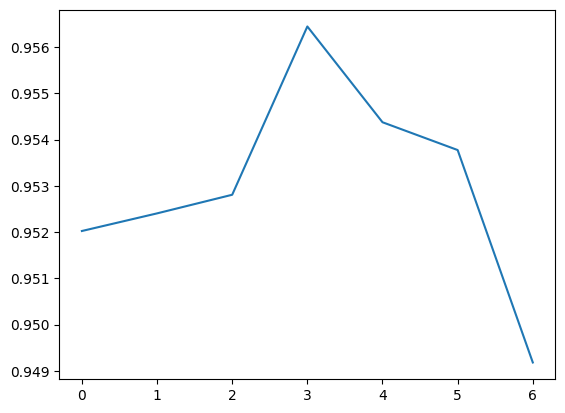

In [25]:
plt.plot(retention_rates)